In [ ]:

import sys, subprocess, importlib.util

def ensure_package(import_name, pip_name=None):
    pip_name = pip_name or import_name
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing {pip_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])

ensure_package("xarray")
ensure_package("statsmodels")
ensure_package("tqdm")


In [ ]:
import os, urllib.request, math, json, zipfile, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import statsmodels.api as sm
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=RuntimeWarning)

# -------------------------
# SETTINGS
# -------------------------
YEAR_MIN, YEAR_MAX = 1950, 2023
SAT_ERA_START = 1979

# Newfoundland geometry
NL_LAT_MIN, NL_LAT_MAX = 44.0, 54.5
NL_LON_MIN, NL_LON_MAX = -61.5, -50.0

NL_PROXY_POINTS = np.array([
    [47.56, -52.71],  # St. John's
    [48.95, -57.95],  # Corner Brook-ish
    [48.70, -53.11],  # Bonavista-ish
    [49.18, -55.74],  # Twillingate-ish
    [51.45, -56.00],  # Labrador proxy
], dtype=float)

PROXY_NAMES = [
    "St. John's (Avalon Peninsula)",
    "Corner Brook region (west coast)",
    "Bonavista region (east-central coast)",
    "Twillingate region (north-central coast)",
    "Labrador coast proxy",
]

# Baseline detection params from recovered code
LAT_GATE_BASE = 25.0
WIN_BASE = 4
ZONAL_KM_THRESH_BASE = 30.0
ZONAL_PRE_MAX_EAST_BASE = 30.0
DIST_KM_THRESH_BASE = 600.0
MIN_TRACK_PTS = 25

# Heading verification thresholds from recovered code
EAST_SIN_THRESH = 0.10
NORTH_COS_THRESH = 0.00
PRE_EAST_MAX = 0.05

# Output folders
OUTDIR = Path("/content/nl_recurvature_outputs_original_method")
FIG_DIR = OUTDIR / "figures"
OUTDIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

EXPECTED_MANUSCRIPT_VALUES = {
    "baseline_n": 167,
    "full_irr": 0.995,
    "full_p": 0.880,
    "satellite_irr": 1.134,
    "satellite_p": 0.112,
    "heading_n": 151,
    "overlap": 146,
    "jaccard": 0.849,
}

print("Output folder:", OUTDIR)


Output folder: /content/nl_recurvature_outputs_original_method


In [ ]:
# -------------------------
# DATA (IBTrACS v04r00 NetCDF, recovered-code source)
# -------------------------
IBTRACS_URL = "https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r00/access/netcdf/IBTrACS.ALL.v04r00.nc"
NC_PATH = "/content/IBTrACS.ALL.v04r00.nc"

if not os.path.exists(NC_PATH):
    print("Downloading IBTrACS ALL v04r00 NetCDF...")
    urllib.request.urlretrieve(IBTRACS_URL, NC_PATH)
else:
    print("Using existing file:", NC_PATH)

ds = xr.open_dataset(NC_PATH)
print(ds)

lat_all = ds["lat"].values.astype(float)
lon_raw = ds["lon"].values.astype(float)
season = ds["season"].values.astype(int)
sid = ds["sid"].values
basin = ds["basin"].values

name_arr = ds["name"].values if "name" in ds.variables else None
time_arr = ds["time"].values if "time" in ds.variables else None


def wrap_lon(lon):
    return ((lon + 180) % 360) - 180

lon_all = wrap_lon(lon_raw)

storm_has_na = (basin == b"NA").any(axis=1)
storm_idx = np.where((season >= YEAR_MIN) & (season <= YEAR_MAX) & storm_has_na)[0]

print("Storms in period with at least one NA basin point:", len(storm_idx))
print("Seasons:", season[storm_idx].min(), season[storm_idx].max())


<xarray.Dataset> Size: 4GB
Dimensions:           (storm: 13811, date_time: 360, quadrant: 4)
Coordinates:
    time              (storm, date_time) datetime64[ns] 40MB ...
    lat               (storm, date_time) float32 20MB ...
    lon               (storm, date_time) float32 20MB ...
Dimensions without coordinates: storm, date_time, quadrant
Data variables: (12/147)
    numobs            (storm) float32 55kB ...
    sid               (storm) |S13 180kB ...
    season            (storm) float32 55kB ...
    number            (storm) int16 28kB ...
    basin             (storm, date_time) |S2 10MB ...
    subbasin          (storm, date_time) |S2 10MB ...
    ...                ...
    reunion_gust      (storm, date_time) float32 20MB ...
    reunion_gust_per  (storm, date_time) float32 20MB ...
    usa_seahgt        (storm, date_time) float32 20MB ...
    usa_searad        (storm, date_time, quadrant) float32 80MB ...
    storm_speed       (storm, date_time) float32 20MB ...
    storm_

In [ ]:
# -------------------------
# HELPERS
# -------------------------
R_EARTH_KM = 6371.0


def decode_bytes_or_str(x):
    if isinstance(x, (bytes, np.bytes_)):
        return x.decode("utf-8", errors="ignore").strip()
    if hasattr(x, "tobytes") and getattr(x, "dtype", None) is not None and x.dtype.kind == "S":
        return x.tobytes().decode("utf-8", errors="ignore").strip(" \x00")
    return str(x).strip()


def decode_sid(x):
    return decode_bytes_or_str(x)


def decode_name_for_index(k):
    if name_arr is None:
        return ""
    try:
        return decode_bytes_or_str(name_arr[k])
    except Exception:
        return ""


def time_for_index(k, i):
    if time_arr is None:
        return ""
    try:
        val = time_arr[k, i]
        if np.isnat(val):
            return ""
        return str(pd.to_datetime(val))
    except Exception:
        return ""


def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2*R_EARTH_KM*np.arcsin(np.sqrt(a))


def min_dist_to_proxy_km(track_lats, track_lons):
    best = np.inf
    best_j = -1
    for j, (plat, plon) in enumerate(NL_PROXY_POINTS):
        d = haversine_km(track_lats, track_lons, plat, plon)
        m = float(np.nanmin(d))
        if m < best:
            best = m
            best_j = j
    return best, best_j


def in_nl_box(lat, lon):
    return (NL_LAT_MIN <= lat) & (lat <= NL_LAT_MAX) & (NL_LON_MIN <= lon) & (lon <= NL_LON_MAX)


def initial_bearing_deg(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlon = lon2 - lon1
    x = np.sin(dlon) * np.cos(lat2)
    y = np.cos(lat1)*np.sin(lat2) - np.sin(lat1)*np.cos(lat2)*np.cos(dlon)
    brng = np.degrees(np.arctan2(x, y))
    return (brng + 360) % 360


def poisson_IRR_from_years(qual_years, year_min=YEAR_MIN, year_max=YEAR_MAX):
    years = pd.Index(range(year_min, year_max+1), name="season")
    s = pd.Series(qual_years).value_counts() if len(qual_years) else pd.Series(dtype=int)
    annual = s.reindex(years, fill_value=0).rename("n").reset_index()

    t = annual["season"].values.astype(float)
    y = annual["n"].values.astype(float)
    tc = t - t.mean()
    X = sm.add_constant(tc)

    res = sm.GLM(y, X, family=sm.families.Poisson()).fit()
    beta1 = float(res.params[1])
    se1 = float(res.bse[1])
    irr = float(np.exp(beta1 * 10))
    lo  = float(np.exp((beta1 - 1.96*se1) * 10))
    hi  = float(np.exp((beta1 + 1.96*se1) * 10))
    p   = float(res.pvalues[1])
    disp = float(res.pearson_chi2 / res.df_resid) if res.df_resid > 0 else np.nan
    return irr, lo, hi, p, disp, annual


def destination_point(lat_deg, lon_deg, bearing_deg, dist_km):
    lat1 = math.radians(lat_deg)
    lon1 = math.radians(lon_deg)
    brng = math.radians(bearing_deg)
    dr = dist_km / R_EARTH_KM
    lat2 = math.asin(math.sin(lat1)*math.cos(dr) + math.cos(lat1)*math.sin(dr)*math.cos(brng))
    lon2 = lon1 + math.atan2(math.sin(brng)*math.sin(dr)*math.cos(lat1),
                             math.cos(dr) - math.sin(lat1)*math.sin(lat2))
    lon2 = (math.degrees(lon2) + 540) % 360 - 180
    return math.degrees(lat2), lon2


In [ ]:
# -------------------------
# RECURREVATURE DETECTORS -
# -------------------------
def recurv_idx_zonal_km(tlat, tlon, lat_gate=LAT_GATE_BASE, win=WIN_BASE,
                        zonal_km_thresh=ZONAL_KM_THRESH_BASE,
                        zonal_pre_max=ZONAL_PRE_MAX_EAST_BASE):
    """Returns (i_star, recurv_lat, recurv_lon) or (None, None, None).

    Preserves recovered-code convention: loop over step index j, assign position index i_star = j + 1.
    """
    if len(tlat) < (2*win + 3):
        return None, None, None

    lon_unwrap = np.degrees(np.unwrap(np.radians(tlon)))
    dlon_deg = np.diff(lon_unwrap)
    midlat = (tlat[:-1] + tlat[1:]) / 2.0
    dlon_rad = np.radians(dlon_deg)
    zonal_km = R_EARTH_KM * np.cos(np.radians(midlat)) * dlon_rad

    if len(zonal_km) < (2*win + 2):
        return None, None, None

    for j in range(win, len(zonal_km) - win):
        i_star = j + 1
        if tlat[i_star] < lat_gate:
            continue
        pre = float(np.mean(zonal_km[j-win:j]))
        post = float(np.mean(zonal_km[j:j+win]))
        if (pre <= zonal_pre_max) and (post > zonal_km_thresh):
            return i_star, float(tlat[i_star]), float(tlon[i_star])
    return None, None, None


def recurv_idx_heading(tlat, tlon, lat_gate=LAT_GATE_BASE, win=WIN_BASE):
    if len(tlat) < (2*win + 3):
        return None, None, None
    b = initial_bearing_deg(tlat[:-1], tlon[:-1], tlat[1:], tlon[1:])
    s = np.sin(np.radians(b))
    c = np.cos(np.radians(b))

    if len(s) < (2*win + 2):
        return None, None, None

    for j in range(win, len(s) - win):
        i_star = j + 1
        if tlat[i_star] < lat_gate:
            continue
        pre_e = float(np.mean(s[j-win:j]))
        post_e = float(np.mean(s[j:j+win]))
        post_n = float(np.mean(c[j:j+win]))
        if pre_e <= PRE_EAST_MAX and post_e > EAST_SIN_THRESH and post_n > NORTH_COS_THRESH:
            return i_star, float(tlat[i_star]), float(tlon[i_star])
    return None, None, None


In [ ]:
# -------------------------
# CLASSIFICATION
# -------------------------
def classify_events(detector="zonal", dist_km_thresh=DIST_KM_THRESH_BASE,
                    lat_gate=LAT_GATE_BASE, win=WIN_BASE,
                    zonal_km_thresh=ZONAL_KM_THRESH_BASE,
                    zonal_pre_max=ZONAL_PRE_MAX_EAST_BASE,
                    min_track_pts=MIN_TRACK_PTS):
    rows_all = []
    rows_relevant = []

    for k in tqdm(storm_idx, desc=f"Scanning storms ({detector})"):
        tr_lat = lat_all[k]
        tr_lon = lon_all[k]
        valid = np.isfinite(tr_lat) & np.isfinite(tr_lon)
        tlat = tr_lat[valid]
        tlon = tr_lon[valid]
        valid_indices = np.where(valid)[0]
        if len(tlat) < min_track_pts:
            continue

        if detector == "zonal":
            i_star, rlat, rlon = recurv_idx_zonal_km(tlat, tlon, lat_gate=lat_gate, win=win,
                                                     zonal_km_thresh=zonal_km_thresh,
                                                     zonal_pre_max=zonal_pre_max)
        elif detector == "heading":
            i_star, rlat, rlon = recurv_idx_heading(tlat, tlon, lat_gate=lat_gate, win=win)
        else:
            raise ValueError("detector must be 'zonal' or 'heading'")

        if i_star is None:
            continue

        post_lat = tlat[i_star:]
        post_lon = tlon[i_star:]
        box_hit = bool(np.any(in_nl_box(post_lat, post_lon)))
        min_d, prox_j = min_dist_to_proxy_km(post_lat, post_lon)
        nl_relevant = bool(box_hit or (min_d <= dist_km_thresh))

        orig_i = int(valid_indices[i_star]) if i_star < len(valid_indices) else int(i_star)
        row = {
            "sid": decode_sid(sid[k]),
            "season": int(season[k]),
            "name": decode_name_for_index(k),
            "detector": detector,
            "distance_threshold_km": float(dist_km_thresh),
            "lat_gate_degN": float(lat_gate),
            "window_steps": int(win),
            "zonal_threshold_km_6h": float(zonal_km_thresh) if detector == "zonal" else np.nan,
            "zonal_pre_max_km_6h": float(zonal_pre_max) if detector == "zonal" else np.nan,
            "recurv_i": int(i_star),
            "recurv_original_time_index": orig_i,
            "recurv_time": time_for_index(k, orig_i),
            "recurv_lat": float(rlat),
            "recurv_lon": float(rlon),
            "box_hit": box_hit,
            "min_dist_km": float(min_d),
            "closest_proxy_idx": int(prox_j),
            "closest_proxy": PROXY_NAMES[prox_j] if prox_j >= 0 else "",
            "nl_relevant": nl_relevant,
        }
        rows_all.append(row)
        if nl_relevant:
            rows_relevant.append(row)

    df_all = pd.DataFrame(rows_all).sort_values(["season", "sid"]).reset_index(drop=True) if rows_all else pd.DataFrame()
    df_rel = pd.DataFrame(rows_relevant).sort_values(["season", "sid"]).reset_index(drop=True) if rows_relevant else pd.DataFrame()
    return df_all, df_rel


def annual_counts_from_events(df_rel, year_min=YEAR_MIN, year_max=YEAR_MAX):
    years = pd.Index(range(year_min, year_max+1), name="season")
    s = df_rel["season"].value_counts() if len(df_rel) else pd.Series(dtype=int)
    return s.reindex(years, fill_value=0).rename("n").reset_index()

# Baseline
zonal_all, df_nl = classify_events(detector="zonal", dist_km_thresh=DIST_KM_THRESH_BASE)
annual = annual_counts_from_events(df_nl)
qual_years = df_nl["season"].tolist()

irr, lo, hi, p, disp, annual_for_model = poisson_IRR_from_years(qual_years)
irr_sat, lo_sat, hi_sat, p_sat, disp_sat, annual_sat = poisson_IRR_from_years(
    [y for y in qual_years if y >= SAT_ERA_START], year_min=SAT_ERA_START, year_max=YEAR_MAX
)

print("Baseline NL-relevant N:", len(df_nl))
print(f"Poisson 1950-2023: IRR={irr:.3f} [{lo:.3f},{hi:.3f}] p={p:.3f} disp={disp:.2f}")
print(f"Poisson 1979-2023: IRR={irr_sat:.3f} [{lo_sat:.3f},{hi_sat:.3f}] p={p_sat:.3f} disp={disp_sat:.2f}")
df_nl.head()


Scanning storms (zonal):   0%|          | 0/1195 [00:00<?, ?it/s]

Baseline NL-relevant N: 167
Poisson 1950-2023: IRR=0.995 [0.926,1.068] p=0.880 disp=1.06
Poisson 1979-2023: IRR=1.134 [0.971,1.323] p=0.112 disp=1.08


,sid,season,name,detector,distance_threshold_km,lat_gate_degN,window_steps,zonal_threshold_km_6h,zonal_pre_max_km_6h,recurv_i,recurv_original_time_index,recurv_time,recurv_lat,recurv_lon,box_hit,min_dist_km,closest_proxy_idx,closest_proxy,nl_relevant
0,1950224N17305,1950,ABLE,zonal,600.0,25.0,4,30.0,30.0,64,64,1950-08-20 00:00:00.000040448,32.799999,-75.199997,True,26.364536,1,Corner Brook region (west coast),True
1,1950234N11334,1950,CHARLIE,zonal,600.0,25.0,4,30.0,30.0,107,107,1950-09-03 21:00:00.000040448,36.434937,-60.437199,False,483.520455,0,St. John's (Avalon Peninsula),True
2,1950243N15304,1950,DOG,zonal,600.0,25.0,4,30.0,30.0,95,95,1950-09-11 15:00:00.000040448,37.179321,-71.731087,False,551.890771,0,St. John's (Avalon Peninsula),True
3,1950270N25309,1950,GEORGE,zonal,600.0,25.0,4,30.0,30.0,54,54,1950-10-04 00:00:00.000040448,34.200001,-68.000000,True,120.532233,0,St. John's (Avalon Peninsula),True
4,1952231N15341,1952,ABLE,zonal,600.0,25.0,4,30.0,30.0,108,108,1952-08-31 18:00:00.000040448,35.400002,-80.599998,False,410.074933,1,Corner Brook region (west coast),True


,month,month_name,n_events,percent_of_events
0,1,January,0,0.0
1,2,February,0,0.0
2,3,March,0,0.0
3,4,April,0,0.0
4,5,May,0,0.0
5,6,June,8,4.8
6,7,July,25,15.0
7,8,August,37,22.2
8,9,September,65,38.9
9,10,October,30,18.0


Seasonality events with valid recurvature time: 167
Peak recurvature month: September (65 events)
Months represented: June, July, August, September, October, November
Saved: /content/nl_recurvature_outputs_original_method/figures/fig_seasonality_recurvature_month.png


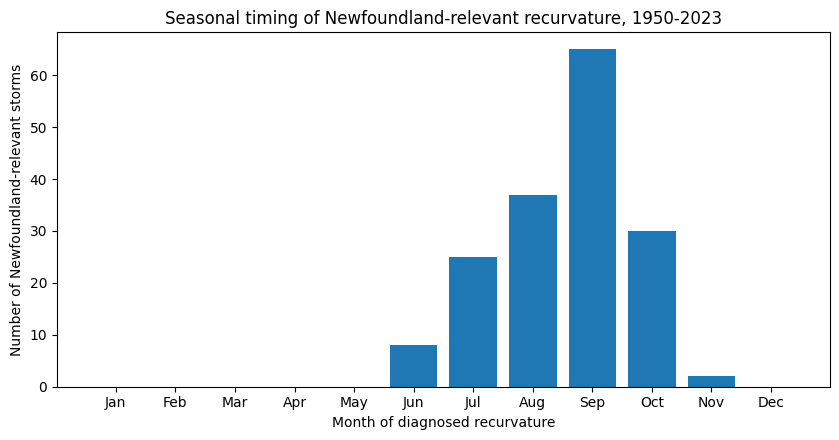


Top three months:


,month_name,n_events
8,September,65
7,August,37
9,October,30



Manuscript helper:
Monthly counts were computed using the month of the diagnosed baseline zonal-translation recurvature point. The distribution peaks in September (n = 65), with the full monthly distribution exported to seasonality_monthly_counts.csv.


Saved: /content/nl_recurvature_outputs_original_method/figures/fig1_annual_counts_trend.png


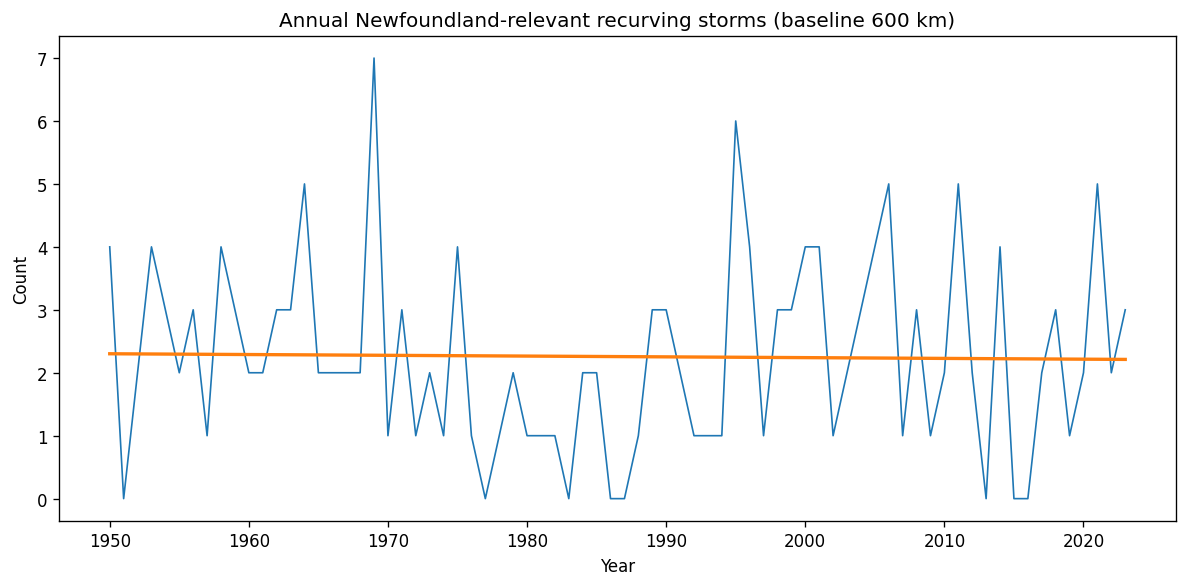

Saved: /content/nl_recurvature_outputs_original_method/figures/fig2_annual_counts_rolling10.png


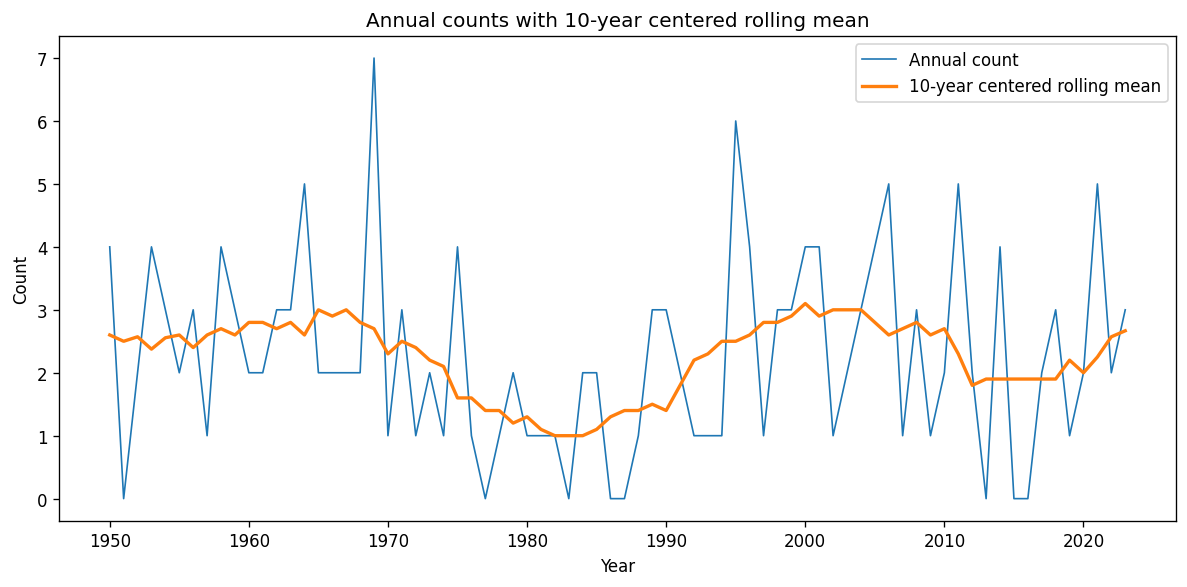

Saved: /content/nl_recurvature_outputs_original_method/figures/fig3_recurvature_scatter_by_era.png


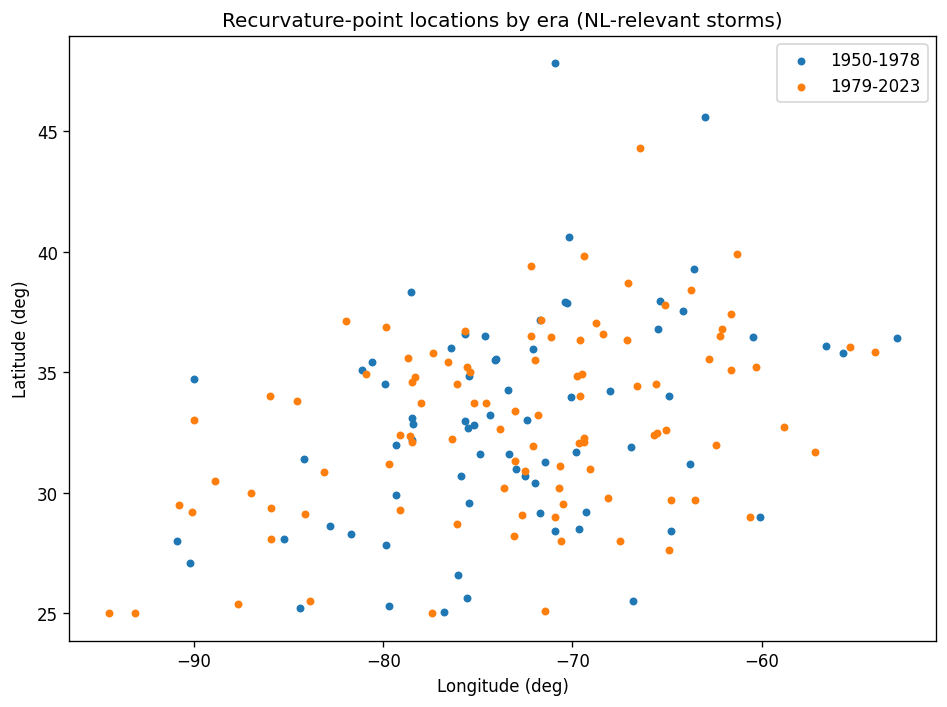

Saved: /content/nl_recurvature_outputs_original_method/figures/fig4_min_distance_trend.png


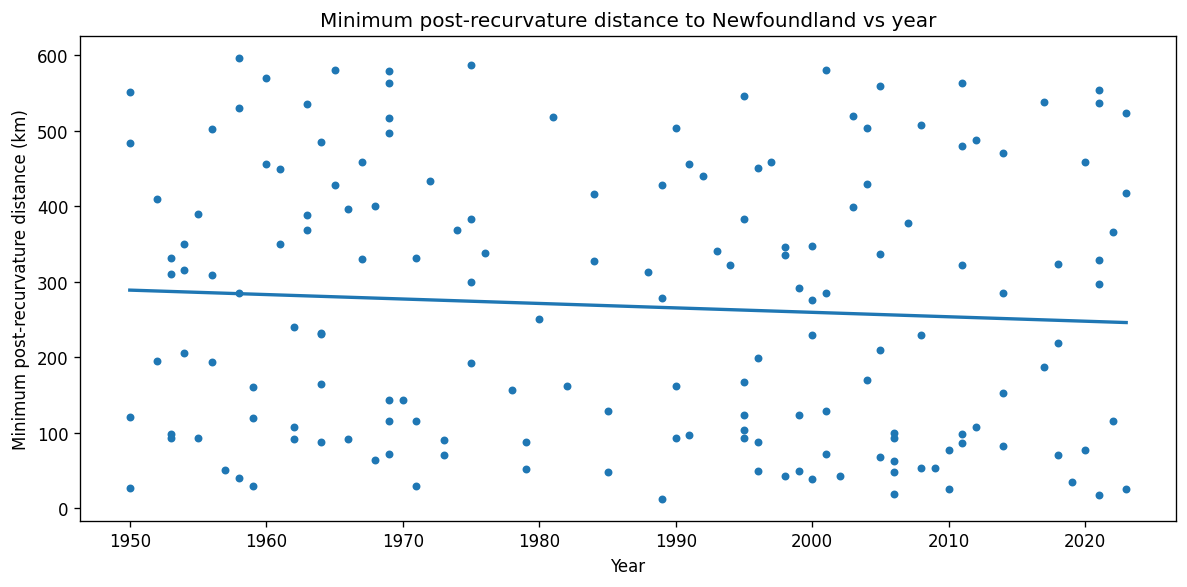

Saved: /content/nl_recurvature_outputs_original_method/figures/fig5_distance_hist_by_era.png


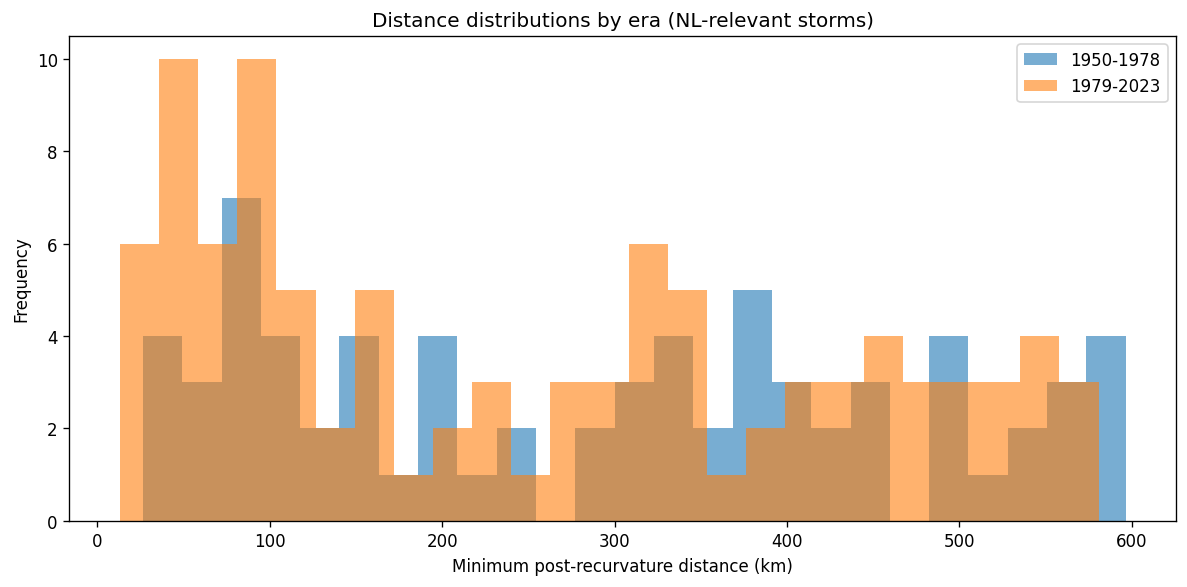

Saved: /content/nl_recurvature_outputs_original_method/figures/fig6_count_distribution.png


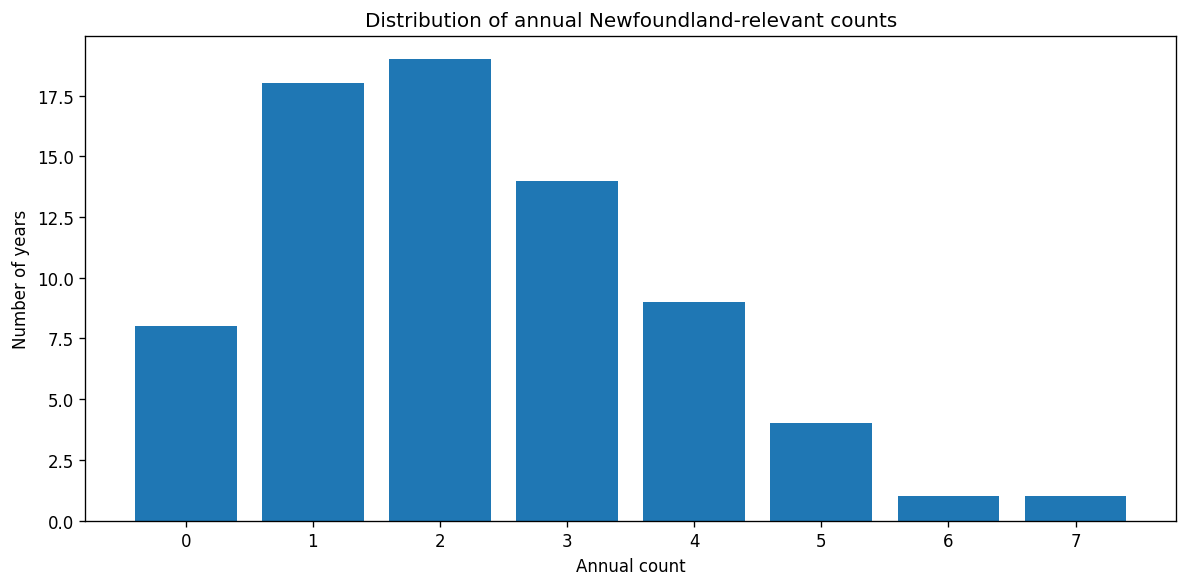

/tmp/ipykernel_982/4032997395.py:89: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=True)


Saved: /content/nl_recurvature_outputs_original_method/figures/fig7_decadal_boxplot.png


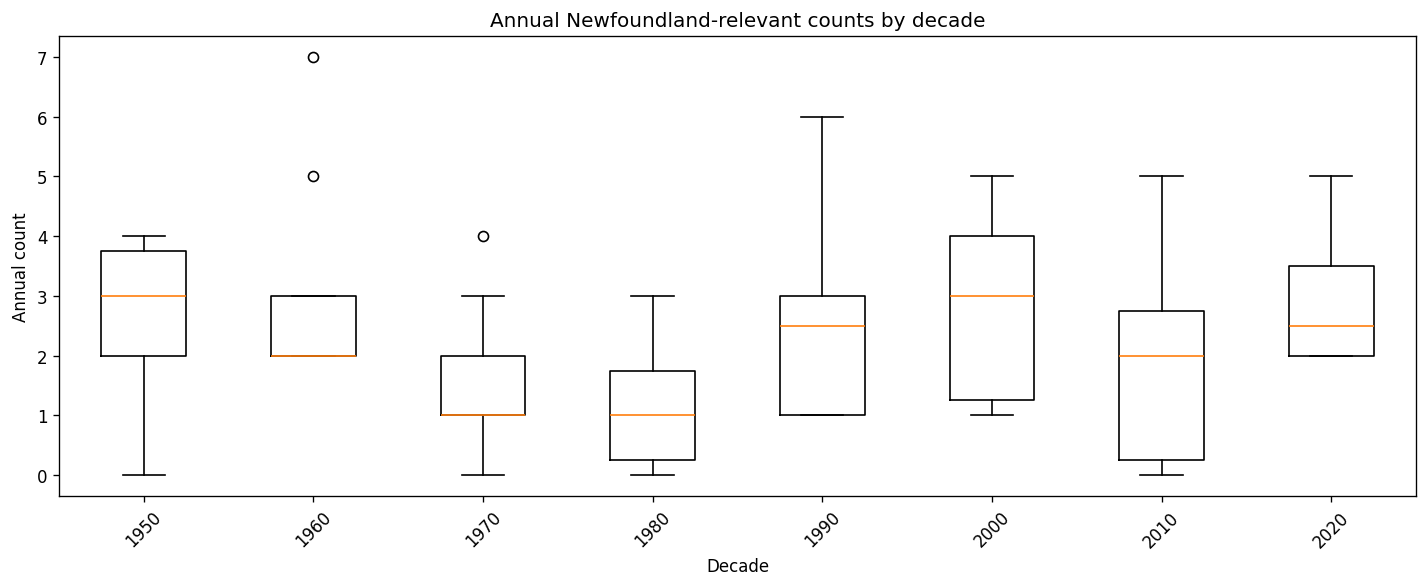

Saved: /content/nl_recurvature_outputs_original_method/figures/fig8_nl_geometry.png


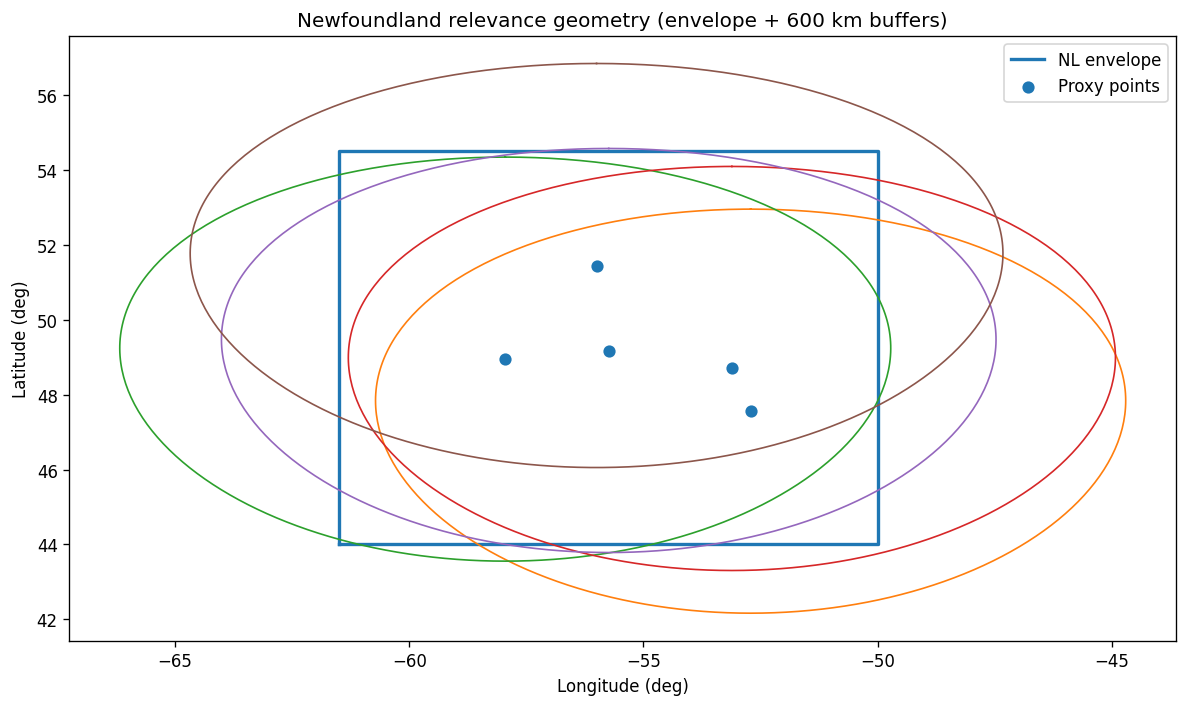

In [ ]:
# -------------------------
# FIGURES
# -------------------------
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 250, "font.size": 10})


def savefig(name):
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    print("Saved:", path)
    plt.show()
    plt.close()

# Figure 1
x = annual["season"].values.astype(float)
y = annual["n"].values.astype(float)
coef = np.polyfit(x, y, 1)
plt.figure(figsize=(10,5))
plt.plot(x, y, linewidth=1)
plt.plot(x, coef[0]*x + coef[1], linewidth=2)
plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Annual Newfoundland-relevant recurving storms (baseline 600 km)")
savefig("fig1_annual_counts_trend.png")

# Figure 2
s = annual.set_index("season")["n"].astype(float)
roll = s.rolling(window=10, center=True, min_periods=5).mean()
plt.figure(figsize=(10,5))
plt.plot(s.index.values, s.values, linewidth=1, label="Annual count")
plt.plot(roll.index.values, roll.values, linewidth=2, label="10-year centered rolling mean")
plt.xlabel("Year")
plt.ylabel("Count")
plt.title("Annual counts with 10-year centered rolling mean")
plt.legend()
savefig("fig2_annual_counts_rolling10.png")

# Figure 3
early = df_nl[df_nl["season"] < SAT_ERA_START]
late = df_nl[df_nl["season"] >= SAT_ERA_START]
plt.figure(figsize=(8,6))
plt.scatter(early["recurv_lon"], early["recurv_lat"], s=14, label=f"{YEAR_MIN}-{SAT_ERA_START-1}")
plt.scatter(late["recurv_lon"], late["recurv_lat"], s=14, label=f"{SAT_ERA_START}-{YEAR_MAX}")
plt.xlabel("Longitude (deg)")
plt.ylabel("Latitude (deg)")
plt.title("Recurvature-point locations by era (NL-relevant storms)")
plt.legend()
savefig("fig3_recurvature_scatter_by_era.png")

# Figure 4
x = df_nl["season"].values.astype(float)
y = df_nl["min_dist_km"].values.astype(float)
coef = np.polyfit(x, y, 1)
plt.figure(figsize=(10,5))
plt.scatter(x, y, s=14)
plt.plot(x, coef[0]*x + coef[1], linewidth=2)
plt.xlabel("Year")
plt.ylabel("Minimum post-recurvature distance (km)")
plt.title("Minimum post-recurvature distance to Newfoundland vs year")
savefig("fig4_min_distance_trend.png")

# Figure 5
plt.figure(figsize=(10,5))
plt.hist(early["min_dist_km"].values, bins=25, alpha=0.6, label=f"{YEAR_MIN}-{SAT_ERA_START-1}")
plt.hist(late["min_dist_km"].values, bins=25, alpha=0.6, label=f"{SAT_ERA_START}-{YEAR_MAX}")
plt.xlabel("Minimum post-recurvature distance (km)")
plt.ylabel("Frequency")
plt.title("Distance distributions by era (NL-relevant storms)")
plt.legend()
savefig("fig5_distance_hist_by_era.png")

# Figure 6
counts = annual["n"].values.astype(int)
vc = pd.Series(counts).value_counts().sort_index()
plt.figure(figsize=(10,5))
plt.bar(vc.index.values.astype(int), vc.values.astype(int))
plt.xlabel("Annual count")
plt.ylabel("Number of years")
plt.title("Distribution of annual Newfoundland-relevant counts")
savefig("fig6_count_distribution.png")

# Figure 7
dec = annual.copy()
dec["decade"] = (dec["season"] // 10) * 10
groups = [g["n"].values for _, g in dec.groupby("decade")]
labels = [str(int(d)) for d in sorted(dec["decade"].unique())]
plt.figure(figsize=(12,5))
plt.boxplot(groups, labels=labels, showfliers=True)
plt.xlabel("Decade")
plt.ylabel("Annual count")
plt.title("Annual Newfoundland-relevant counts by decade")
plt.xticks(rotation=45)
savefig("fig7_decadal_boxplot.png")

# Figure 8 geometry, non-cartopy original-style
rect_lons = [NL_LON_MIN, NL_LON_MAX, NL_LON_MAX, NL_LON_MIN, NL_LON_MIN]
rect_lats = [NL_LAT_MIN, NL_LAT_MIN, NL_LAT_MAX, NL_LAT_MAX, NL_LAT_MIN]
plt.figure(figsize=(10,6))
plt.plot(rect_lons, rect_lats, linewidth=2, label="NL envelope")
plt.scatter(NL_PROXY_POINTS[:,1], NL_PROXY_POINTS[:,0], s=40, label="Proxy points")
bearings = np.linspace(0, 360, 361)
for (plat, plon) in NL_PROXY_POINTS:
    circle_lat, circle_lon = [], []
    for b in bearings:
        lat2, lon2 = destination_point(float(plat), float(plon), float(b), DIST_KM_THRESH_BASE)
        circle_lat.append(lat2)
        circle_lon.append(lon2)
    plt.plot(circle_lon, circle_lat, linewidth=1)
plt.xlabel("Longitude (deg)")
plt.ylabel("Latitude (deg)")
plt.title(f"Newfoundland relevance geometry (envelope + {int(DIST_KM_THRESH_BASE)} km buffers)")
plt.legend()
savefig("fig8_nl_geometry.png")


In [ ]:
# -------------------------
# SENSITIVITY TABLES
# -------------------------
def distance_sensitivity_table(dist_list_km=(300, 500, 600, 800)):
    rows = []
    for d in dist_list_km:
        _, tmp = classify_events(detector="zonal", dist_km_thresh=float(d),
                                 lat_gate=LAT_GATE_BASE, win=WIN_BASE,
                                 zonal_km_thresh=ZONAL_KM_THRESH_BASE,
                                 zonal_pre_max=ZONAL_PRE_MAX_EAST_BASE)
        irr, lo, hi, p, disp, _ = poisson_IRR_from_years(tmp["season"].tolist())
        rows.append({
            "threshold_km": int(d),
            "n_storms": int(len(tmp)),
            "irr_per_decade": irr,
            "ci_low": lo,
            "ci_high": hi,
            "p": p,
            "dispersion": disp,
        })
    return pd.DataFrame(rows)


def recurv_sensitivity_table(lat_gates=(25,30), wins=(3,4,5), thresholds_km=(20,30,40), dist_km=600.0):
    rows = []
    for lat_gate in lat_gates:
        for win in wins:
            for thr in thresholds_km:
                _, tmp = classify_events(detector="zonal", dist_km_thresh=float(dist_km),
                                         lat_gate=float(lat_gate), win=int(win),
                                         zonal_km_thresh=float(thr),
                                         zonal_pre_max=float(thr))
                irr, lo, hi, p, disp, _ = poisson_IRR_from_years(tmp["season"].tolist())
                rows.append({
                    "lat_gate_degN": float(lat_gate),
                    "window_steps": int(win),
                    "zonal_thresh_km_6h": float(thr),
                    "n_storms": int(len(tmp)),
                    "irr_per_decade": irr,
                    "ci_low": lo,
                    "ci_high": hi,
                    "p": p,
                    "dispersion": disp,
                })
    return pd.DataFrame(rows)


distance_sensitivity = distance_sensitivity_table()
recurv_sensitivity = recurv_sensitivity_table()

display(distance_sensitivity)
display(recurv_sensitivity)


Scanning storms (zonal):   0%|          | 0/1195 [00:00<?, ?it/s]

Scanning storms (zonal):   0%|          | 0/1195 [00:00<?, ?it/s]

Scanning storms (zonal):   0%|          | 0/1195 [00:00<?, ?it/s]

Scanning storms (zonal):   0%|          | 0/1195 [00:00<?, ?it/s]

Scanning storms (zonal):   0%|          | 0/1195 [00:00<?, ?it/s]

...

Scanning storms (zonal):   0%|          | 0/1195 [00:00<?, ?it/s]

Scanning storms (zonal):   0%|          | 0/1195 [00:00<?, ?it/s]

Scanning storms (zonal):   0%|          | 0/1195 [00:00<?, ?it/s]

,threshold_km,n_storms,irr_per_decade,ci_low,ci_high,p,dispersion
0,300,120,1.011575,0.930278,1.099976,0.787753,1.002802
1,500,145,1.002800,0.929222,1.082204,0.942661,0.884345
2,600,167,0.994568,0.926394,1.067759,0.880494,1.060019
3,800,228,0.987294,0.929071,1.049166,0.680094,1.023364


,lat_gate_degN,window_steps,zonal_thresh_km_6h,n_storms,irr_per_decade,ci_low,ci_high,p,dispersion
0,25.0,3,20.0,167,1.007311,0.938261,1.081442,0.840653,1.082808
1,25.0,3,30.0,173,1.004381,0.936698,1.076954,0.902267,1.048121
2,25.0,3,40.0,175,0.989720,0.923386,1.060818,0.770323,1.051734
3,25.0,4,20.0,167,1.007575,0.938507,1.081727,0.834992,1.057635
4,25.0,4,30.0,167,0.994568,0.926394,1.067759,0.880494,1.060019
5,25.0,4,40.0,173,0.997153,0.929958,1.069204,0.936169,1.037240
6,25.0,5,20.0,165,1.014520,0.944556,1.089666,0.692542,1.049525
7,25.0,5,30.0,166,0.996178,0.927697,1.069715,0.916078,1.087788
8,25.0,5,40.0,172,1.000127,0.932544,1.072609,0.997152,1.029053
9,30.0,3,20.0,145,1.015771,0.941219,1.096229,0.687425,1.067326


In [ ]:
# -------------------------
# HEADING VERIFICATION
# -------------------------
heading_all, heading_events = classify_events(detector="heading", dist_km_thresh=DIST_KM_THRESH_BASE)
heading_years = heading_events["season"].tolist()
h_irr, h_lo, h_hi, h_p, h_disp, heading_annual = poisson_IRR_from_years(heading_years)

zonal_set = set(df_nl["sid"])
heading_set = set(heading_events["sid"])
overlap = len(zonal_set & heading_set)
union = len(zonal_set | heading_set)
jaccard = overlap / union if union else np.nan

method_comparison = pd.DataFrame([{
    "zonal_n": len(zonal_set),
    "heading_n": len(heading_set),
    "overlap": overlap,
    "only_zonal": len(zonal_set - heading_set),
    "only_heading": len(heading_set - zonal_set),
    "jaccard": jaccard,
    "heading_irr_per_decade": h_irr,
    "heading_ci_low": h_lo,
    "heading_ci_high": h_hi,
    "heading_p": h_p,
    "heading_dispersion": h_disp,
}])

display(method_comparison)


Scanning storms (heading):   0%|          | 0/1195 [00:00<?, ?it/s]

,zonal_n,heading_n,overlap,only_zonal,only_heading,jaccard,heading_irr_per_decade,heading_ci_low,heading_ci_high,heading_p,heading_dispersion
0,167,151,146,21,5,0.848837,1.021056,0.947545,1.10027,0.584648,1.020387


In [ ]:
# -------------------------
# MANUSCRIPT COMPARISON + EXPORTS
# -------------------------
trend_summary = pd.DataFrame([
    {"start_year": YEAR_MIN, "end_year": YEAR_MAX, "n_years": YEAR_MAX-YEAR_MIN+1, "total_events": len(df_nl),
     "irr_per_decade": irr, "ci_low": lo, "ci_high": hi, "p": p, "dispersion": disp},
    {"start_year": SAT_ERA_START, "end_year": YEAR_MAX, "n_years": YEAR_MAX-SAT_ERA_START+1, "total_events": int((df_nl["season"] >= SAT_ERA_START).sum()),
     "irr_per_decade": irr_sat, "ci_low": lo_sat, "ci_high": hi_sat, "p": p_sat, "dispersion": disp_sat},
])

check_rows = [
    {"quantity": "baseline_n", "reconstructed": len(df_nl), "manuscript": EXPECTED_MANUSCRIPT_VALUES["baseline_n"]},
    {"quantity": "full_irr", "reconstructed": irr, "manuscript": EXPECTED_MANUSCRIPT_VALUES["full_irr"]},
    {"quantity": "full_p", "reconstructed": p, "manuscript": EXPECTED_MANUSCRIPT_VALUES["full_p"]},
    {"quantity": "satellite_irr", "reconstructed": irr_sat, "manuscript": EXPECTED_MANUSCRIPT_VALUES["satellite_irr"]},
    {"quantity": "satellite_p", "reconstructed": p_sat, "manuscript": EXPECTED_MANUSCRIPT_VALUES["satellite_p"]},
    {"quantity": "heading_n", "reconstructed": len(heading_events), "manuscript": EXPECTED_MANUSCRIPT_VALUES["heading_n"]},
    {"quantity": "overlap", "reconstructed": overlap, "manuscript": EXPECTED_MANUSCRIPT_VALUES["overlap"]},
    {"quantity": "jaccard", "reconstructed": jaccard, "manuscript": EXPECTED_MANUSCRIPT_VALUES["jaccard"]},
]
reconstruction_check = pd.DataFrame(check_rows)
reconstruction_check["difference"] = reconstruction_check["reconstructed"] - reconstruction_check["manuscript"]

def round_table(df):
    out = df.copy()
    for c in out.columns:
        if pd.api.types.is_float_dtype(out[c]):
            out[c] = out[c].round(3)
    return out

# CSV exports
zonal_all.to_csv(OUTDIR / "storm_metrics_baseline_600km_all_recurving.csv", index=False)
df_nl.to_csv(OUTDIR / "baseline_zonal_events_600km.csv", index=False)
heading_events.to_csv(OUTDIR / "heading_events_600km.csv", index=False)
annual.to_csv(OUTDIR / "annual_counts_baseline_600km.csv", index=False)
trend_summary.to_csv(OUTDIR / "trend_summary.csv", index=False)
distance_sensitivity.to_csv(OUTDIR / "table2_distance_sensitivity.csv", index=False)
recurv_sensitivity.to_csv(OUTDIR / "table3_recurvature_sensitivity.csv", index=False)
method_comparison.to_csv(OUTDIR / "heading_method_comparison.csv", index=False)
reconstruction_check.to_csv(OUTDIR / "reconstruction_check_against_manuscript.csv", index=False)
pd.DataFrame({"proxy_location": PROXY_NAMES, "lat": NL_PROXY_POINTS[:,0], "lon": NL_PROXY_POINTS[:,1]}).to_csv(OUTDIR / "newfoundland_proxy_points.csv", index=False)

# LaTeX snippets
with open(OUTDIR / "table2_distance_sensitivity_latex.txt", "w") as f:
    f.write(round_table(distance_sensitivity).to_latex(index=False, escape=False))

with open(OUTDIR / "table3_recurvature_sensitivity_latex_resizebox.txt", "w") as f:
    f.write("% Requires \\usepackage{graphicx}. This prevents the table from running off the page.\n")
    f.write("\\begin{table}[H]\n\\centering\n")
    f.write("\\caption{Sensitivity of Newfoundland-relevant classification and Poisson trend inference to recurvature detection parameters (distance threshold fixed at 600~km). Zonal threshold is expressed in km per 6~h.}\n")
    f.write("\\label{tab:recurv_sens}\n")
    f.write("\\resizebox{\\textwidth}{!}{%\n")
    f.write(round_table(recurv_sensitivity).to_latex(index=False, escape=False))
    f.write("}\n\\end{table}\n")

summary = {
    "settings": {
        "data_source": IBTRACS_URL,
        "year_min": YEAR_MIN,
        "year_max": YEAR_MAX,
        "satellite_start": SAT_ERA_START,
        "lat_gate": LAT_GATE_BASE,
        "window": WIN_BASE,
        "zonal_threshold_km_6h": ZONAL_KM_THRESH_BASE,
        "zonal_pre_max_km_6h": ZONAL_PRE_MAX_EAST_BASE,
        "distance_threshold_km": DIST_KM_THRESH_BASE,
        "min_track_pts": MIN_TRACK_PTS,
        "recurvature_index_convention": "i_star = j + 1 from recovered code",
    },
    "full_trend": trend_summary.iloc[0].to_dict(),
    "satellite_trend": trend_summary.iloc[1].to_dict(),
    "method_comparison": method_comparison.iloc[0].to_dict(),
}

if "seasonality_monthly_counts" in globals():
    peak_idx = seasonality_monthly_counts["n_events"].idxmax()
    peak = seasonality_monthly_counts.loc[peak_idx]
    summary["seasonality"] = {
        "definition": "Month of diagnosed baseline zonal recurvature point",
        "events_with_valid_recurv_time": int(seasonality_monthly_counts["n_events"].sum()),
        "peak_month": str(peak["month_name"]),
        "peak_month_events": int(peak["n_events"]),
        "monthly_counts_csv": "seasonality_monthly_counts.csv",
        "monthly_counts_figure": "figures/fig_seasonality_recurvature_month.png",
    }

with open(OUTDIR / "analysis_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)

zip_path = Path("/content/nl_recurvature_outputs_original_method.zip")
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for pth in OUTDIR.rglob("*"):
        z.write(pth, arcname=str(pth.relative_to(OUTDIR)))

print("Key reconstruction check:")
display(reconstruction_check)
print("Created zip:", zip_path)

try:
    from google.colab import files
    files.download(str(zip_path))
except Exception:
    print("Download manually from:", zip_path)


Key reconstruction check:


,quantity,reconstructed,manuscript,difference
0,baseline_n,167.000000,167.000,0.000000
1,full_irr,0.994568,0.995,-0.000432
2,full_p,0.880494,0.880,0.000494
3,satellite_irr,1.133544,1.134,-0.000456
4,satellite_p,0.111682,0.112,-0.000318
5,heading_n,151.000000,151.000,0.000000
6,overlap,146.000000,146.000,0.000000
7,jaccard,0.848837,0.849,-0.000163


Created zip: /content/nl_recurvature_outputs_original_method.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

=== TIME-STEP AUDIT: RECURRENCE DETECTION WINDOWS ===
Rows: 334
Events audited: 167

Window interval counts:
window
pre_window     167
post_window    167
Name: count, dtype: int64

All detection-window intervals exactly 6 h?
False

Rows with any non-6 h intervals:
334


,sid,season,name,window,n_intervals,min_dt_h,median_dt_h,max_dt_h,all_6h,any_non6h,dt_values
1,1950224N17305,1950,ABLE,post_window,4,3.0,3.0,3.0,False,True,"3.00,3.00,3.00,3.00"
0,1950224N17305,1950,ABLE,pre_window,4,3.0,3.0,3.0,False,True,"3.00,3.00,3.00,3.00"
3,1950234N11334,1950,CHARLIE,post_window,4,3.0,3.0,3.0,False,True,"3.00,3.00,3.00,3.00"
2,1950234N11334,1950,CHARLIE,pre_window,4,3.0,3.0,3.0,False,True,"3.00,3.00,3.00,3.00"
5,1950243N15304,1950,DOG,post_window,4,3.0,3.0,3.0,False,True,"3.00,3.00,3.00,3.00"
4,1950243N15304,1950,DOG,pre_window,4,3.0,3.0,3.0,False,True,"3.00,3.00,3.00,3.00"
7,1950270N25309,1950,GEORGE,post_window,4,3.0,3.0,3.0,False,True,"3.00,3.00,3.00,3.00"
6,1950270N25309,1950,GEORGE,pre_window,4,3.0,3.0,3.0,False,True,"3.00,3.00,3.00,3.00"
9,1952231N15341,1952,ABLE,post_window,4,3.0,3.0,3.0,False,True,"3.00,3.00,3.00,3.00"
8,1952231N15341,1952,ABLE,pre_window,4,3.0,3.0,3.0,False,True,"3.00,3.00,3.00,3.00"



Distribution of all interval lengths used in detection windows:
dt_hours
0.25       2
0.50       4
0.67       1
1.00       7
1.25       1
1.50       2
1.75       1
2.00       8
2.33       1
2.50       4
2.75       2
3.00    1303
Name: count, dtype: int64

Summary:
count    1336.000000
mean        2.963323
std         0.260302
min         0.250000
25%         3.000000
50%         3.000000
75%         3.000000
max         3.000000
Name: dt_hours, dtype: float64

Saved: /content/time_step_audit_detection_windows.csv


## What To Check

The final `reconstruction_check_against_manuscript.csv` should tell you whether this recovered original-method notebook reproduces the manuscript. If it lands back on `N = 167` and the old IRR values, keep the current manuscript numbers and update the methods to explicitly mention:

- IBTrACS ALL v04r00 NetCDF source, filtered to storms with at least one North Atlantic basin point.
- Valid storm tracks required at least 25 valid latitude-longitude points.
- The recurvature point is assigned at `i_star = j + 1`, with post-recurvature relevance evaluated from that point onward.
